In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

print("GROQ_API_KEY exists:", bool(os.getenv("GROQ_API_KEY")))


GROQ_API_KEY exists: True


In [2]:
import pandas as pd

df=pd.read_csv("../dataset/Book(Sheet1).csv",encoding="latin1")
df.sample(5)

,No,Scheme Name,Unnamed: 2,Scheme Details,Benifits,Elligibility,Application processs,documents required,url
7,8,AGR 2 (Farm Mechanization) Scheme Of Farmers O...,NaN,The scheme AGR 2 (Farm Mechanization) Scheme ...,1.\tThe beneficiary will get financial assista...,The beneficiary should be a permanent resident...,"Step 01: To avail the benefits of the scheme, ...",Government-approved photo ID i.e. Aadhaar Card...,https://ikhedut.gujarat.gov.in/site/
15,16,Use of Advanced Drone Technology (Agriculture ...,NaN,"The ""Use of Advanced Drone Technology (Agricul...",Name of Scheme and Standard of assistanceFinan...,The beneficiary should be land holder.The bene...,Step 1: The applicant may visit and apply onli...,Aadhar Card (Mandatory).Land Ownership Documen...,https://ikhedut.gujarat.gov.in/site/
12,13,Use of Advanced Drone Technology (Agriculture ...,NaN,"The ""Use of Advanced Drone Technology (Agricul...",Name of Scheme and Standard of assistanceFinan...,The beneficiary should be land holder.The bene...,Step 1: The applicant may visit and apply onli...,Aadhar Card (Mandatory).Land Ownership Documen...,https://ikhedut.gujarat.gov.in/site/
19,20,Scheme to Provide Financial Assistance to Purc...,NaN,"The ""Scheme to Provide Financial Assistance to...",Name of the ComponentStandard of AssistanceMin...,For Individual Farmers:\nThe applicant must be...,Online\nStep 1: The applicant may visit and ap...,Aadhaar Card.8-A Land Record Document (for joi...,https://ikhedut.gujarat.gov.in/
1,2,Gujarat Ikhedut Portal Schemes,NaN,NaN,Ikhedut Portal is the official digital platfor...,The applicant must be a permanent resident of ...,Farmers do not need to apply separately for th...,Aadhaar Card\n7/12 Land Record\nBank Passbook\...,https://ikhedut.gujarat.gov.in/site/


In [3]:
df.columns

Index(['No', 'Scheme Name', 'Unnamed: 2', 'Scheme Details', 'Benifits',
       'Elligibility', 'Application processs', 'documents required', 'url'],
      dtype='object')

In [4]:
df = df.drop(columns=["Unnamed: 2"], errors="ignore")

df = df.rename(columns={
    "Scheme Name": "scheme_name",
    "Scheme Details": "scheme_details",
    "Benifits": "benefits",
    "Elligibility": "eligibility",
    "Application processs": "application_process",
    "documents required": "documents_required",
    "url": "url"
})

df.head()


,No,scheme_name,scheme_details,benefits,eligibility,application_process,documents_required,url
0,1,Mukhyamantri Kisan Sahay Yojana (Gujarat),Mukhya Mantri Kisan Sahay Yojana is implemente...,"Under the Mukhyamantri Kisan Sahay Yojana, the...","To apply under this scheme, the applicant must...",Step-by-step Application Process:\n\nVisit the...,The following documents are required while app...,https://www.myscheme.gov.in/schemes/mksy
1,2,Gujarat Ikhedut Portal Schemes,NaN,Ikhedut Portal is the official digital platfor...,The applicant must be a permanent resident of ...,Farmers do not need to apply separately for th...,Aadhaar Card\n7/12 Land Record\nBank Passbook\...,https://ikhedut.gujarat.gov.in/site/
2,3,Krushi Mahotsav Yojana (Gujarat),NaN,Agriculture Scientists and officers are provid...,All farmers and Female farmers of the state.Th...,Government teams visit villages during Krushi ...,No documents are required.Land documents (to g...,https://www.myscheme.gov.in/schemes/km
3,4,Soil Health Card Scheme (Gujarat),NaN,Provides free soil testing and nutrient recomm...,Any registered farmer of Gujarat.,Apply through agriculture office or soil testi...,Land Record\nAadhaar Card,NaN
4,5,Gujarat Micro Irrigation Scheme,The scheme Assistance for Installation of Spr...,Provides subsidy for drip and sprinkler irriga...,Farmer must own or cultivate agricultural land...,Apply via Ikhedut Portal.\nUpload documents.\n...,Land Record\nAadhaar\nBank Passbook,https://ikhedut.gujarat.gov.in/site/


In [5]:
df["combined_text"] = (
    "Scheme Name: " + df["scheme_name"].astype(str) +
    ". Details: " + df["scheme_details"].astype(str) +
    ". Benefits: " + df["benefits"].astype(str) +
    ". Eligibility: " + df["eligibility"].astype(str) +
    ". Application Process: " + df["application_process"].astype(str) +
    ". Documents Required: " + df["documents_required"].astype(str)
)

In [6]:
df.columns

Index(['No', 'scheme_name', 'scheme_details', 'benefits', 'eligibility',
       'application_process', 'documents_required', 'url', 'combined_text'],
      dtype='object')

In [7]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.2
)

print("Groq LLM loaded successfully ✅")



c:\Users\LENOVO\Documents\DCS\kisaanai\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Groq LLM loaded successfully ✅


# Generate Emmbeddings and retriving data using similarity

In [ ]:
from sentence_transformers import SentenceTransformer

# Lightweight, free, fast – best for text data
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded ✅")
embedding_model.save("models/embedding_model")

print("Embedding model saved ✅")

Embedding model loaded ✅


In [10]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
# Generate embeddings for all schemes
embedding_model = SentenceTransformer("models/embedding_model")
scheme_embeddings = embedding_model.encode(
    df["combined_text"].tolist(),
    show_progress_bar=True
)

# Create FAISS index
dimension = scheme_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)

faiss_index.add(np.array(scheme_embeddings))

print("FAISS index created with", faiss_index.ntotal, "schemes ✅")


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]

FAISS index created with 21 schemes ✅


In [11]:
def semantic_retrieval_node(state, top_k=3):
    """
    Semantic retrieval using FAISS embeddings.
    Updates state['retrieved_schemes']
    """

    query = state["query"]

    # Encode query
    query_vector = embedding_model.encode([query])

    # Search FAISS index
    distances, indices = faiss_index.search(query_vector, top_k)

    # Retrieve scheme rows
    retrieved = df.iloc[indices[0]].to_dict(orient="records")

    # Update state
    state["intent"] = "semantic"
    state["retrieved_schemes"] = retrieved

    return state


In [12]:
def add_user_message(state: SchemeAgentState, message: str):
    state["query"] = message
    state["chat_history"].append({
        "role": "user",
        "content": message
    })


NameError: name 'SchemeAgentState' is not defined

In [ ]:
state = init_state()

add_user_message(state, "Small farmers ke liye subsidy schemes batao")

state


{'query': 'Small farmers ke liye subsidy schemes batao',
 'chat_history': [{'role': 'user',
   'content': 'Small farmers ke liye subsidy schemes batao'}],
 'intent': None,
 'retrieved_schemes': None,
 'response': None,
 'language': 'hinglish'}

### Embedding testing

In [ ]:
# Initialize state
state = init_state()

# Add user query
add_user_message(state, "schems for the economical weaker category")

# Run semantic retrieval
state = semantic_retrieval_node(state)

# Inspect results
print("Intent:", state["intent"])
print("Number of schemes:", len(state["retrieved_schemes"]))
state

Intent: semantic
Number of schemes: 3


{'query': 'schems for the economical weaker category',
 'chat_history': [{'role': 'user',
   'content': 'schems for the economical weaker category'}],
 'intent': 'semantic',
 'retrieved_schemes': [{'No': 8,
   'scheme_name': 'AGR 2 (Farm Mechanization) Scheme Of Farmers Other Than SC/ST',
   'scheme_details': 'The scheme \x93AGR 2 (Farm Mechanization) Scheme of Farmers Other Than SC/ST\x94 was started by the Department of Agriculture, Farmers Welfare & Co-operation, Government of Gujarat. Under the scheme, financial assistance is given to the farmers for the purchase of agricultural equipment to increase production of agricultural crops.\n          The state government has launched the scheme to make agricultural industries successful through the use of agricultural mechanization. The farmer can get good quality and more farm produce at low cost by maximizing and utilizing natural, unimplemented sources such as land, water, and atmosphere due to agricultural mechanization. Thus, in ord

In [ ]:
for i, scheme in enumerate(state["retrieved_schemes"], 1):
    print(f"{i}. {scheme['scheme_name']}")


1. Gujarat Micro Irrigation Scheme
2. Agro Service Provider Scheme
3. Mukhyamantri Kisan Sahay Yojana (Gujarat)


# Langhraph Pipeline

- ## Define state

In [13]:
from typing import TypedDict, Annotated, Optional, List, Dict, Any
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class KisaanAIState(TypedDict):
    # Full conversation memory (auto-appended)
    messages: Annotated[list[BaseMessage], add_messages]

    # Retrieved documents from RAG
    retrieved_docs: Optional[List[Dict[str, Any]]]

    # Final answer text
    response: Optional[str]


- ## Define Nodes

In [14]:
def semantic_search_node(state: KisaanAIState):
    user_query = state["messages"][-1].content

    # Encode query
    query_embedding = embedding_model.encode([user_query])

    # Search FAISS
    distances, indices = faiss_index.search(query_embedding, k=3)

    docs = []
    for idx in indices[0]:
        row = df.iloc[idx]
        docs.append({
            "scheme_name": row["scheme_name"],
            "details": row["scheme_details"],
            "benefits": row["benefits"],
            "eligibility": row["eligibility"],
            "application_process": row["application_process"],
            "documents_required": row["documents_required"],
            "url": row["url"]
        })

    return {"retrieved_docs": docs}


In [15]:
from langchain_core.messages import SystemMessage, AIMessage

def answer_node(state: KisaanAIState):
    context = "\n\n".join(
        f"""
Scheme Name: {d['scheme_name']}
Details: {d['details']}
Benefits: {d['benefits']}
Eligibility: {d['eligibility']}
Application Process: {d['application_process']}
Documents Required: {d['documents_required']}
URL: {d['url']}
"""
        for d in state["retrieved_docs"]
    )

    system_prompt = f"""
You are KisaanAI – a government scheme assistant for Indian farmers.

Rules:
- Answer in simple Hinglish
- Use ONLY the given context
- If something is not available, say clearly
- Be practical and short

Context:
{context}
"""

    messages = [
        SystemMessage(content=system_prompt),
        *state["messages"]
    ]

    ai_reply = llm.invoke(messages).content

    return {
        "messages": [AIMessage(content=ai_reply)],
        "response": ai_reply
    }


- ## Graph structure

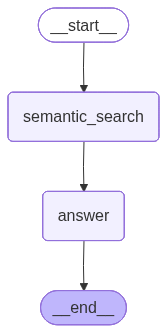

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(KisaanAIState)

graph.add_node("semantic_search", semantic_search_node)
graph.add_node("answer", answer_node)

graph.add_edge(START, "semantic_search")
graph.add_edge("semantic_search", "answer")
graph.add_edge("answer", END)

workflow = graph.compile(checkpointer=InMemorySaver())
workflow


- ## Testing

In [64]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "farmer-001"}}

# First question
workflow.invoke(
    {"messages": [HumanMessage(content="PM Kisan scheme kya hai?")]},
    config=config
)

# Follow-up question (context auto-used)
workflow.invoke(
    {"messages": [HumanMessage(content="Isme kaunse documents chahiye?")]},
    config=config
)


{'messages': [HumanMessage(content='PM Kisan scheme kya hai?', additional_kwargs={}, response_metadata={}, id='36c0805f-78d2-479c-9e52-b6207b504b3d'),
  AIMessage(content='PM Kisan Yojana ek pramukh yojana hai jo Bharat sarkar dwara lagu ki gayi hai. Is yojana ke under, kisanon ko prati varsh 6,000 rupaye ki rashi di jati hai. Is yojana ka lakshya kisanon ko aarthik sahayata pradan karna hai aur unki aay mein sudhar karna hai.\n\nPM Kisan Yojana ka prarambh 2018 mein hua tha. Is yojana ke under, kisanon ko prati varsh 6,000 rupaye ki rashi di jati hai, jismein 2,000 rupaye prati varsh ka pratham kist, 2,000 rupaye prati varsh ka doosra kist aur 2,000 rupaye prati varsh ka teesra kist shamil hai.\n\nKisan PM Kisan Yojana ke liye online aavedan kar sakte hain. Unhein apne aas-paas ke kshetra mein sarkari karyalay ya bank branch par jaakar aavedan karne ki aavashyakata nahin hai.', additional_kwargs={}, response_metadata={}, id='310fab61-3a4e-4665-8f8f-edb607dcc509'),
  HumanMessage(conte

In [65]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "farmer-001"}}

print("KisaanAI Chat Started (type 'exit' to stop)\n")

while True:
    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit", "stop"]:
        print("KisaanAI: Dhanyavaad! 👋")
        break

    result = workflow.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    # Only print last AI message
    ai_message = result["messages"][-1].content
    print("KisaanAI:", ai_message)
    print()


KisaanAI Chat Started (type 'exit' to stop)

KisaanAI: Bharat mein kuch pramukh yojanaein hain jo aarthik tarkon ke kisanon ke liye uplabdh hain:

1. **PM Kisan Yojana**: Is yojana ke under, kisanon ko prati varsh 6,000 rupaye ki rashi di jati hai.
2. **Mukhya Mantri Krishi Saathi Yojana**: Is yojana ke under, kisanon ko 50% ki rashi di jati hai jiska upyog unhone kheti ke liye kiya hai.
3. **Mukhya Mantri Krishi Udyami Yojana**: Is yojana ke under, kisanon ko 50% ki rashi di jati hai jiska upyog unhone kheti ke liye kiya hai.
4. **National Agriculture Insurance Scheme (NAIS)**: Is yojana ke under, kisanon ko kheti ke liye hui nuksan ki raksha di jati hai.
5. **Mukhya Mantri Krishi Upchar Yojana**: Is yojana ke under, kisanon ko kheti ke liye upchar ki sambhavana pradan ki jati hai.
6. **Mukhya Mantri Krishi Samridhi Yojana**: Is yojana ke under, kisanon ko kheti ke liye sambhavana pradan ki jati hai aur unhein 50% ki rashi di jati hai.
7. **Mukhya Mantri Krishi Vikas Yojana**: Is yoja

# Crop disease Agent

In [17]:
import pandas as pd
df_disease=pd.read_csv("../dataset/gujarat_top100_crops_diseases.csv")
df_disease.sample(5)

,Crop,Disease,Farmer_Symptoms,Technical_Symptoms,Treatment,Prevention,RecoveryTime
298,Lucerne (Alfalfa),Leaf Blight,Large necrotic patches on leaves,Exserohilum/Helminthosporium blight,Mancozeb sprays,"Balanced fertilization, avoid dense stands",2-3 weeks
311,Tapioca (Cassava),Powdery Mildew,White powdery coating on leaves,Erysiphales superficial mycelium,Sulfur or triazole fungicides,"Good airflow, avoid overcrowding",1-2 weeks
305,Cluster Bean (Guar),Ascochyta/Leaf Spot,Brown spots on leaves and pods,Ascochyta/Cercospora lesions with halos,Mancozeb/chlorothalonil sprays,"Avoid overhead irrigation, sanitize debris",2-3 weeks
278,Cardamom,Leaf Blight,Brown necrotic lesions on leaves,Alternaria/Cercospora leaf blight,Mancozeb sprays,"Sanitation, balanced nutrition",2-3 weeks
344,Elephant Foot Yam,Powdery Mildew,White powdery coating on leaves,Erysiphales superficial mycelium,Sulfur or triazole fungicides,"Good airflow, avoid overcrowding",1-2 weeks


In [18]:
df.columns


Index(['No', 'scheme_name', 'scheme_details', 'benefits', 'eligibility',
       'application_process', 'documents_required', 'url', 'combined_text'],
      dtype='object')

In [20]:
df_disease["combined_text"] = (
    "Crop: " + df_disease["Crop"].astype(str) +
    ". Disease: " + df_disease["Disease"].astype(str) +
    ". Farmer Symptoms: " + df_disease["Farmer_Symptoms"].astype(str) +
    ". Technical Symptoms: " + df_disease["Technical_Symptoms"].astype(str) +
    ". Treatment: " + df_disease["Treatment"].astype(str) +
    ". Prevention: " + df_disease["Prevention"].astype(str)
)
df_disease = df_disease.dropna(subset=["combined_text"])
df_disease = df_disease.reset_index(drop=True)


In [21]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("models/embedding_model")

disease_embeddings = embedding_model.encode(
    df_disease["combined_text"].tolist(),
    show_progress_bar=True
)

dimension = disease_embeddings.shape[1]
disease_faiss_index = faiss.IndexFlatL2(dimension)
disease_faiss_index.add(np.array(disease_embeddings))

print("Disease FAISS index created with", disease_faiss_index.ntotal, "records ✅")


Batches: 100%|██████████| 13/13 [00:08<00:00,  1.53it/s]

Disease FAISS index created with 414 records ✅


In [22]:
faiss.write_index(disease_faiss_index, "models/disease_faiss.index")
np.save("models/disease_embeddings.npy", disease_embeddings)

print("Disease FAISS index saved ✅")


Disease FAISS index saved ✅


In [23]:
import faiss
import numpy as np

disease_faiss_index = faiss.read_index("models/disease_faiss.index")
disease_embeddings = np.load("models/disease_embeddings.npy")

print("Disease FAISS index loaded with", disease_faiss_index.ntotal, "records ✅")


Disease FAISS index loaded with 414 records ✅


- ## state

In [24]:
from typing import TypedDict, Annotated, Optional, List, Dict, Any
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class DiseaseAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    retrieved_docs: Optional[List[Dict[str, Any]]]
    response: Optional[str]

In [25]:
from langchain_core.messages import HumanMessage

def disease_semantic_node(state: DiseaseAgentState):
    user_query = state["messages"][-1].content

    query_embedding = embedding_model.encode([user_query])
    distances, indices = disease_faiss_index.search(query_embedding, k=3)

    docs = []
    for idx in indices[0]:
        row = df_disease.iloc[idx]
        docs.append({
            "crop": row["Crop"],
            "disease": row["Disease"],
            "farmer_symptoms": row["Farmer_Symptoms"],
            "technical_symptoms": row["Technical_Symptoms"],
            "treatment": row["Treatment"],
            "prevention": row["Prevention"],
            "recovery_time": row["RecoveryTime"]
        })

    return {"retrieved_docs": docs}


In [26]:
from langchain_core.messages import SystemMessage, AIMessage

def disease_answer_node(state: DiseaseAgentState):
    context = "\n\n".join(
        f"""
Crop: {d['crop']}
Disease: {d['disease']}
Farmer Symptoms: {d['farmer_symptoms']}
Technical Symptoms: {d['technical_symptoms']}
Treatment: {d['treatment']}
Prevention: {d['prevention']}
Recovery Time: {d['recovery_time']}
"""
        for d in state["retrieved_docs"]
    )

    system_prompt = f"""
You are KisaanAI – an expert crop disease assistant.

Rules:
- Use only the given context
- Answer in simple Hinglish
- Give practical treatment steps
- If info missing, say clearly

Context:
{context}
"""

    messages = [
        SystemMessage(content=system_prompt),
        *state["messages"]
    ]

    reply = llm.invoke(messages).content

    return {
        "messages": [AIMessage(content=reply)],
        "response": reply
    }


In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

disease_graph = StateGraph(DiseaseAgentState)

disease_graph.add_node("disease_search", disease_semantic_node)
disease_graph.add_node("disease_answer", disease_answer_node)

disease_graph.add_edge(START, "disease_search")
disease_graph.add_edge("disease_search", "disease_answer")
disease_graph.add_edge("disease_answer", END)

disease_workflow = disease_graph.compile(checkpointer=InMemorySaver())


In [28]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "disease-001"}}

print("Crop Disease Agent Started (type exit to stop)\n")

while True:
    user_input = input("You: ")

    if user_input.lower() == "exit":
        print("KisaanAI: Dhanyavaad! 🌱")
        break

    result = disease_workflow.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    print("KisaanAI:", result["messages"][-1].content)
    print()


Crop Disease Agent Started (type exit to stop)

KisaanAI: Maine kuchh karna band kar diya hai.

KisaanAI: Dhanyavaad! 🌱


# Orchestrator layer

In [29]:
class OrchestratorState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    route: Optional[str]   # "scheme" | "disease" | "crop" | "price"
    response: Optional[str]

In [31]:
def call_scheme_agent(state: OrchestratorState):
    result = workflow.invoke(
        {"messages": state["messages"]},
        config={"configurable": {"thread_id": "scheme-thread"}}
    )
    return {"messages": [result["messages"][-1]], "response": result["messages"][-1].content}
def call_disease_agent(state: OrchestratorState):
    result = disease_workflow.invoke(
        {"messages": state["messages"]},
        config={"configurable": {"thread_id": "disease-thread"}}
    )
    return {"messages": [result["messages"][-1]], "response": result["messages"][-1].content}

In [32]:
VALID_ROUTES = ["disease", "scheme", "price"]

def route_query(state):
    query = state["messages"][-1].content.lower()

    disease_keywords = ["bimari", "disease", "symptom", "rog", "pest", "infection"]
    scheme_keywords = ["yojana", "scheme", "subsidy"]

    if any(k in query for k in disease_keywords):
        return "disease"

    if any(k in query for k in scheme_keywords):
        return "scheme"

    # LLM fallback
    prompt = f"""
Classify this farming query into one of:
[disease, scheme]

Query: {query}
Return only one word.
"""
    intent = llm.invoke(prompt).content.strip().lower()

    if intent not in ["disease", "scheme"]:
        return "disease"   # safe default

    return intent


In [33]:
from langgraph.graph import StateGraph, START, END

router_graph = StateGraph(OrchestratorState)

router_graph.add_node("router", routing_node)
router_graph.add_node("scheme_agent", call_scheme_agent)
router_graph.add_node("disease_agent", call_disease_agent)

router_graph.add_edge(START, "router")

router_graph.add_conditional_edges(
    "router",
    route_query,
    {
        "disease": "disease_agent",
        "scheme": "scheme_agent",
    }
)

router_graph.add_edge("scheme_agent", END)
router_graph.add_edge("disease_agent", END)

orchestrator = router_graph.compile()


In [34]:
from langchain_core.messages import HumanMessage

print("KisaanAI Master Agent (type exit)\n")

while True:
    q = input("You: ")
    if q == "exit":
        break

    result = orchestrator.invoke(
        {"messages": [HumanMessage(content=q)]}
    )

    print("KisaanAI:", result["messages"][-1].content)
    print()


KisaanAI Master Agent (type exit)

KisaanAI: SC/ST farmers ke liye kuchh mahatvapurn yojanaein hain:

1. **Mukhyamantri Kisan Sahay Yojana (Gujarat)**: Is yojana ke under SC/ST farmers ko bhi financial assistance milta hai jab unke khet mein natural calamities ke karan nuksan hota hai.
2. **National Mission For Sustainable Agriculture-Parmparagat Krishi Vikas Yojana (NMSA-PKVY)**: Is yojana ke under SC/ST farmers ko organic farming ke liye financial assistance milta hai.
3. **Krushi Mahotsav Yojana (Gujarat)**: Is yojana ke under SC/ST farmers ko free kit distribution milta hai aur unhein agriculture-related information aur guidance milta hai.

In yojanaon ke liye aap I-Khedut Portal par online registration kar sakte hain ya apne neeche ki E-Gram Centre par ja sakte hain.

KisaanAI: Tomato me kai rog ho sakte hain. Main aapko 3 pramukh rog ke baare mein batata hoon:

1. **Late Blight**: Is rog ke symptoms mein taza, pani se bhari cheechein hoti hain, aur thandi, garmi ke mausam mein ye

In [1]:
import pandas as pd


In [2]:
df=pd.read_csv(r"C:\Users\LENOVO\Documents\DCS\Projects\kisaanai\dataset\agri_schemes_full.csv")

In [3]:
df.sample(5)

,slug,scheme_name,state,implementing_agency,nodal_department,benefit_type,target_beneficiaries,tags,category,scheme_details,benefits,eligibility,application_process,documents,url,last_verified,api_id,search_text
375,anby,Atma Nirbhar Bagwani Yojana,Arunachal Pradesh,NaN,Horticulture Department,Cash,Individual,Subsidy|Farmers|Umbrella Scheme,"Agriculture,Rural & Environment",Atma Nirbhar Bagwani Yojana is an umbrella sch...,\n - Atmanirbhar Bagwani Yojna is basically m...,The applicant must be a resident and farmer of...,The interested farmer/SHG/FPO is required to s...,NaN,https://www.myscheme.gov.in/schemes/anby,2026-03-16,64665631527a0d6debce7649,Atma Nirbhar Bagwani Yojana Atma Nirbhar Bagwa...
806,scuccocsc,Scheduled Castes Unsalaried Credit Co-operativ...,Gujarat,NaN,"Agriculture, Farmers Welfare and Cooperation D...",Cash,Registered Societies,Scheduled Caste|Co-operative Societies|Compute...,"Agriculture,Rural & Environment",The scheme “Scheduled Castes Unsalaried Credit...,\n- **Managerial Assistance:** A maximum of ₹8...,\n - The society must be registered under the...,**Step 1:** The interested applicant should pr...,NaN,https://www.myscheme.gov.in/schemes/scuccocsc,2026-03-16,688c9a84746baf0b8676ddfc,Scheduled Castes Unsalaried Credit Co-operativ...
179,fvy,Phool Vikash Yojana,Bihar,NaN,Agriculture Department,Cash,Individual,Agriculture|Subsidy|Plant Supply|Financial Ass...,"Agriculture,Rural & Environment",The “Phool Vikash Yojana” launched by the Depa...,\n - **Financial Assistance:** 50% subsidy on...,\n 1. The applicant should be a resident of ...,> **DBT Registration Process:**\n\n**Step 1:**...,NaN,https://www.myscheme.gov.in/schemes/fvy,2026-03-16,674707a0317b2851b10b2d6e,Phool Vikash Yojana The “Phool Vikash Yojana” ...
897,pm-mkssy-1a,Pradhan Mantri Matsya Kisan Samridhi Sah-yojan...,NaN,NaN,Department of Fisheries,Composite,Individual,Fisheries|Enterprise|Aquaculture|Value Chain,"Business & Entrepreneurship|Banking,Financial ...",The scheme &quot;Pradhan Mantri Matsya Kisan S...,\n- The financial assistance is provided in th...,\n- The applicant must be a fisheries microent...,The application process for availing benefits ...,NaN,https://www.myscheme.gov.in/schemes/pm-mkssy-1a,2026-03-16,685901eb6b245e34fadf5477,Pradhan Mantri Matsya Kisan Samridhi Sah-yojan...
909,ehsap,Employee Health Scheme,Andhra Pradesh,Chief Ministers’ Relief Fund (CMRF),"Department Health, Medical and Family Welfare",Composite,NaN,Health Coverage|Government Employees|Cashless ...,Health & Wellness,"The Dr YSR Aarogyasri Health Care Trust, under...",NaN,1. Serving employees:\n\n- All regular State G...,NaN,NaN,https://www.myscheme.gov.in/schemes/ehsap,2026-03-16,641b1c6c8ed5b17cf6fc2463,Employee Health Scheme The Dr YSR Aarogyasri H...


In [4]:
df.isnull().sum()

slug                       0
scheme_name                0
state                    121
implementing_agency      776
nodal_department          24
benefit_type               0
target_beneficiaries      15
tags                       0
category                   0
scheme_details             0
benefits                  62
eligibility                0
application_process       62
documents               1091
url                        0
last_verified              0
api_id                     0
search_text                0
dtype: int64

In [5]:
df.shape

(1091, 18)